In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.style.use("default")   # quay về style mặc định (nền trắng)

# set defaults for matplotlib
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.7
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.color'] = 'gray'
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.9
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Cấu hình font Times New Roman
plt.rcParams['font.family'] = 'Dejavu serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'  # Để hiển thị math text đúng
plt.rcParams['font.size'] = 12  # Font size mặc định

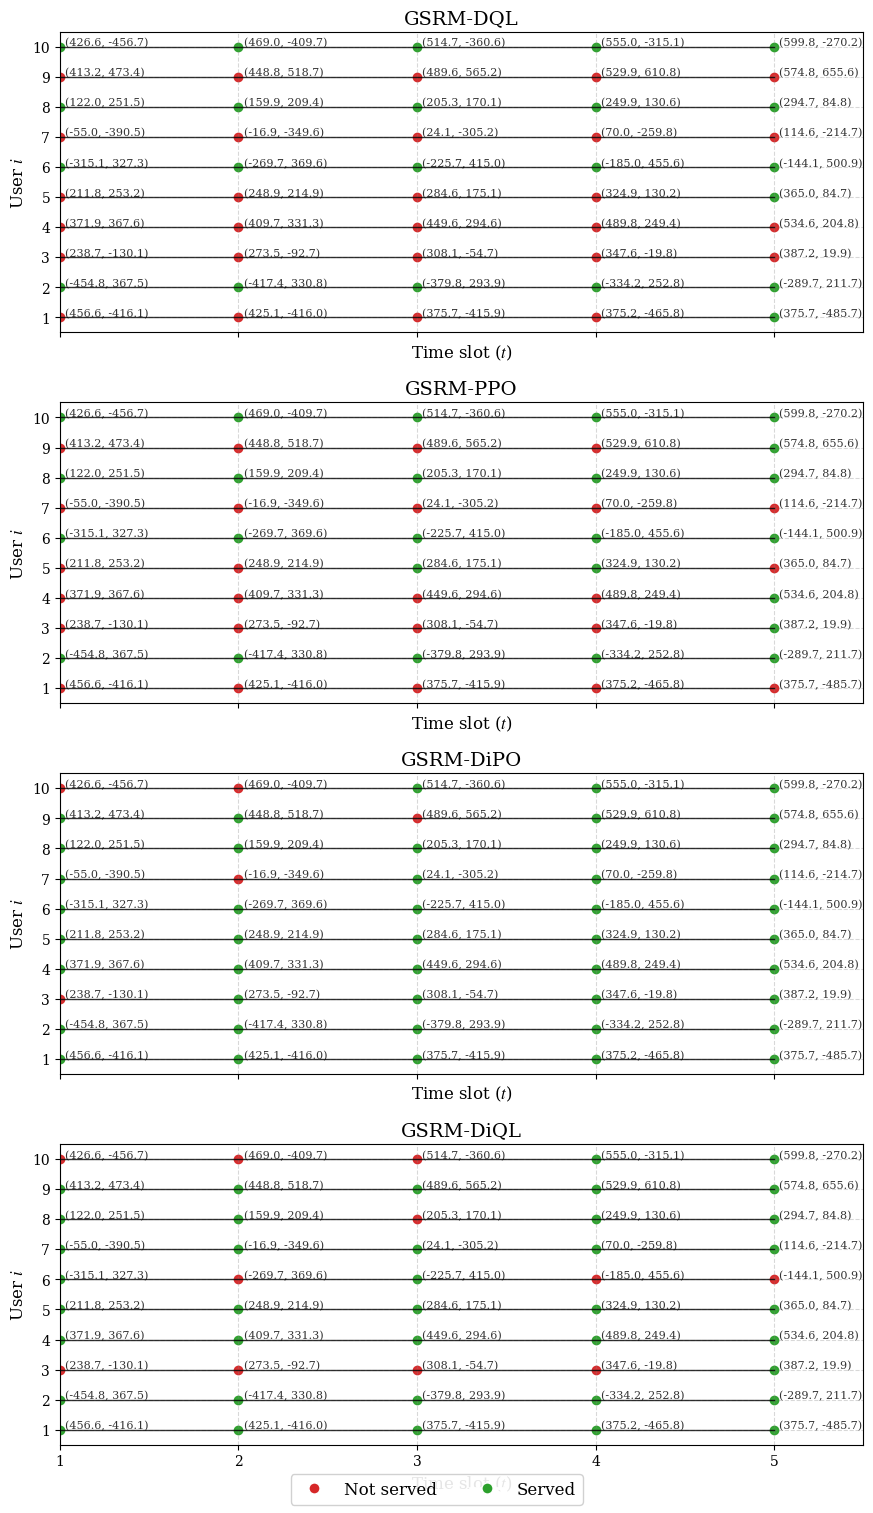

In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

base_dir = Path("outputs")
merged_file = base_dir / "mobility_timestep_user_all_agents_ep_5.csv"

served_columns = {
    "gaussian_dql": "served_gaussian_dql",
    "gaussian_ppo": "served_gaussian_ppo",
    "ppo_diffusion": "served_ppo_diffusion",
    "ql_diffusion": "served_ql_diffusion",
}

agent_names_display = {
    "ppo_diffusion": "GSRM-DiPO",
    "ql_diffusion": "GSRM-DiQL",
    "gaussian_ppo": "GSRM-PPO",
    "gaussian_dql": "GSRM-DQL",
}

df_all = pd.read_csv(merged_file)
df_all["timestep"] = df_all["timestep"].astype(int)
df_all["user_id_1based"] = df_all["user_id_1based"].astype(int)

for col in served_columns.values():
    if col in df_all.columns and df_all[col].dtype != bool:
        df_all[col] = df_all[col].astype(str).str.lower().isin(["true", "1", "yes"])

fig, axes = plt.subplots(4, 1, figsize=(9, 16), sharex=True, sharey=True)
axes = axes.ravel()

for ax, agent in zip(axes, served_columns.keys()):
    col = served_columns[agent]
    if col not in df_all.columns:
        ax.set_title(f"{agent} (missing column: {col})")
        ax.axis("off")
        continue

    df = df_all[["timestep", "user_id_1based", "x", "y", col]].copy()
    df = df.rename(columns={col: "served"}).sort_values(["user_id_1based", "timestep"])

    for uid, g in df.groupby("user_id_1based"):
        ax.plot(g["timestep"], g["user_id_1based"], color="black", linewidth=1, alpha=0.8)

    not_served = df[~df["served"]]
    served = df[df["served"]]
    ax.scatter(not_served["timestep"], not_served["user_id_1based"], c="tab:red", s=36, alpha=0.95)
    ax.scatter(served["timestep"], served["user_id_1based"], c="tab:green", s=36, alpha=0.95)

    for _, r in df.iterrows():
        ax.text(
            r["timestep"] + 0.03,
            r["user_id_1based"] + 0.03,
            f"({r['x']:.1f}, {r['y']:.1f})",
            fontsize=8,
            alpha=0.8,
        )

    ax.set_title(agent_names_display.get(agent, agent))
    ax.set_xlabel(r"Time slot ($t$)")
    ax.set_ylabel(r"User $i$")
    ax.grid(alpha=0.3)

    ts = sorted(df["timestep"].unique().tolist())
    uids = sorted(df["user_id_1based"].unique().tolist())
    ax.set_xticks(ts)
    ax.set_yticks(uids)
    ax.set_xlim(min(ts), max(ts) + 0.5)
    ax.set_ylim(min(uids) - 0.5, max(uids) + 0.5)

for i in range(len(served_columns), len(axes)):
    axes[i].axis("off")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Not served', markerfacecolor='tab:red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Served', markerfacecolor='tab:green', markersize=8),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

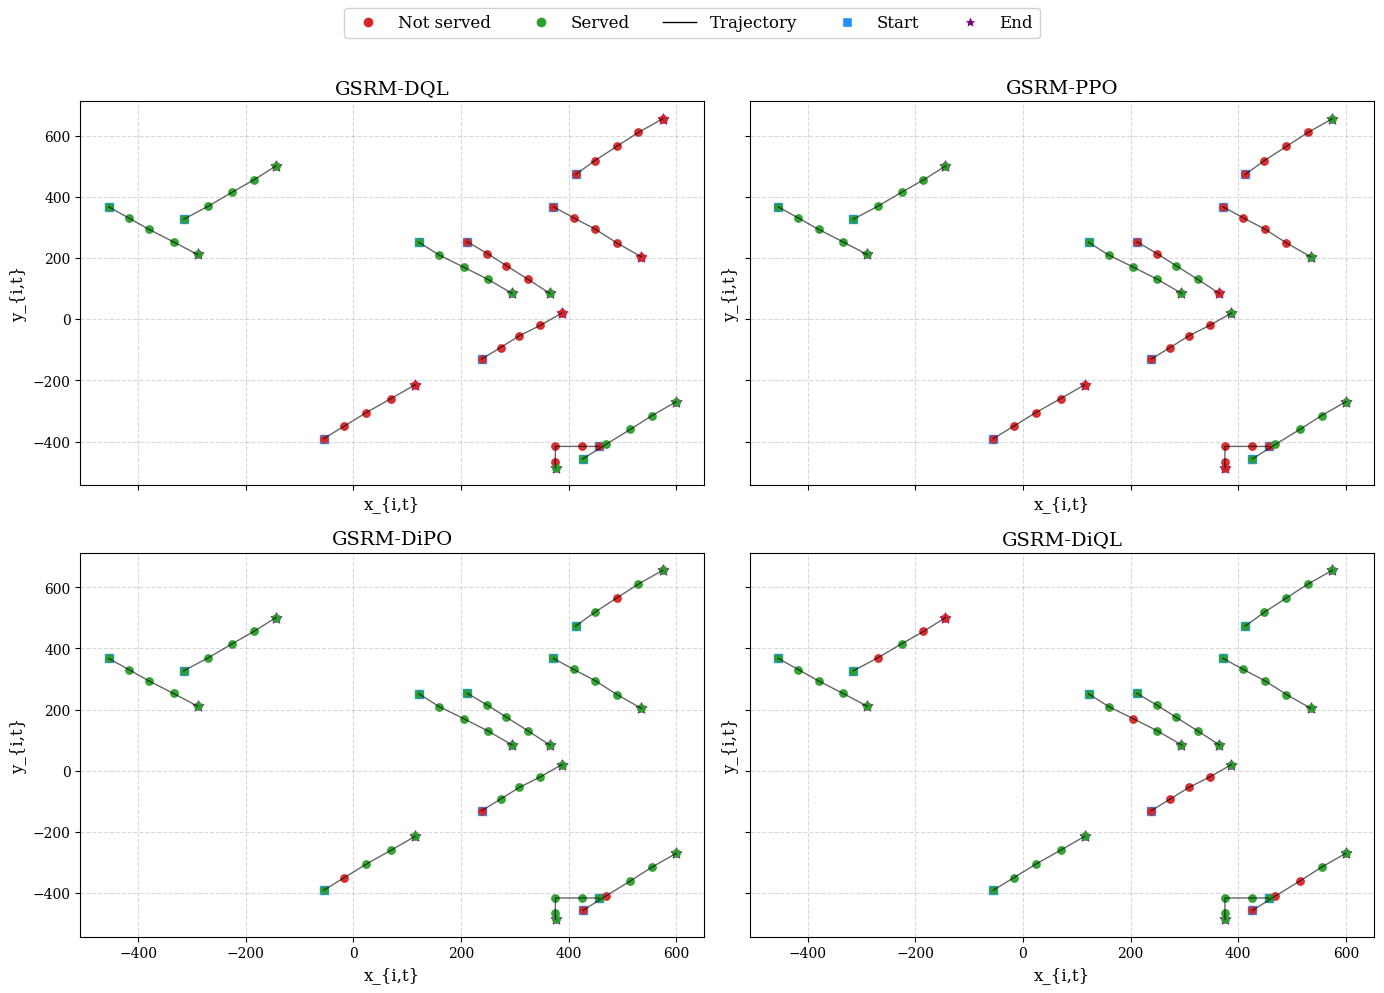

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

if "df_all" not in globals() or "served_columns" not in globals() or "agent_names_display" not in globals():
    base_dir = Path("outputs")
    merged_file = base_dir / "mobility_timestep_user_all_agents_ep_5.csv"
    assert merged_file.exists(), f"Missing merged file: {merged_file}"
    df_all = pd.read_csv(merged_file)
    served_columns = {
        "gaussian_dql": "served_gaussian_dql",
        "gaussian_ppo": "served_gaussian_ppo",
        "ppo_diffusion": "served_ppo_diffusion",
        "ql_diffusion": "served_ql_diffusion",
    }
    agent_names_display = {
        "ppo_diffusion": "GSRM-DiPO",
        "ql_diffusion": "GSRM-DiQL",
        "gaussian_ppo": "GSRM-PPO",
        "gaussian_dql": "GSRM-DQL",
    }

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.ravel()

for ax, agent in zip(axes, served_columns.keys()):
    col = served_columns[agent]
    if col not in df_all.columns:
        ax.set_title(f"{agent} (missing: {col})")
        ax.axis("off")
        continue

    df = df_all[["timestep", "user_id_1based", "x", "y", col]].copy()
    if df[col].dtype != bool:
        df[col] = df[col].astype(str).str.lower().isin(["true", "1", "yes"])
    df = df.rename(columns={col: "served"}).sort_values(["user_id_1based", "timestep"])

    # Nối trajectory theo user trong mặt phẳng x-y
    for uid, g in df.groupby("user_id_1based"):
        ax.plot(g["x"], g["y"], color="black", linewidth=1, alpha=0.6)

        # Đánh dấu điểm đầu/cuối cho dễ nhìn
        g2 = g.sort_values("timestep")
        ax.scatter(g2.iloc[0]["x"], g2.iloc[0]["y"], marker="s", c="dodgerblue", s=30, alpha=0.9)
        ax.scatter(g2.iloc[-1]["x"], g2.iloc[-1]["y"], marker="*", c="purple", s=60, alpha=0.9)

    not_served = df[~df["served"]]
    served = df[df["served"]]
    ax.scatter(not_served["x"], not_served["y"], c="tab:red", s=28, alpha=0.95)
    ax.scatter(served["x"], served["y"], c="tab:green", s=28, alpha=0.95)

    ax.set_title(agent_names_display.get(agent, agent))
    ax.set_xlabel(r"x_{i,t}")
    ax.set_ylabel(r"y_{i,t}")
    ax.grid(alpha=0.3)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Not served', markerfacecolor='tab:red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Served', markerfacecolor='tab:green', markersize=8),
    Line2D([0], [0], color='black', lw=1, label='Trajectory'),
    Line2D([0], [0], marker='s', color='w', label='Start', markerfacecolor='dodgerblue', markersize=7),
    Line2D([0], [0], marker='*', color='w', label='End', markerfacecolor='purple', markersize=10),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=5, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()